In [1]:
# ============================================================
# Mini Project: Gender and Age Detection
# Dataset: UTKFace (aligned & cropped)
# Model: MobileNetV2 + Multi-output heads
# Platform: Google Colab
# ============================================================

In [2]:
# -----------------------------
# 1. Install packages
# -----------------------------
!pip -q install datasets tensorflow scikit-learn seaborn pillow

In [3]:
# -----------------------------
# 2. Imports
# -----------------------------
import os
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
# -----------------------------
# 3. Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
# -----------------------------
# 4. Configuration
# -----------------------------
IMG_SIZE = 96
BATCH_SIZE = 16
EPOCHS_FROZEN = 5
EPOCHS_FINE = 3
MAX_SAMPLES = 4000   # increase to 12000+ if you have more Colab time/GPU
AUTOTUNE = tf.data.AUTOTUNE
AGE_MAX = 116.0      # UTKFace official max age

In [6]:
# -----------------------------
# 5. Load dataset
# -----------------------------
# Public Hugging Face mirror of UTKFace cropped/aligned dataset
ds = load_dataset("py97/UTKFace-Cropped", split="train")

print("Total rows in dataset:", len(ds))
print("Example item keys:", ds[0].keys())

# Shuffle once for reproducibility
ds = ds.shuffle(seed=SEED)

# Use subset for quicker Colab training
if MAX_SAMPLES is not None and MAX_SAMPLES < len(ds):
    ds = ds.select(range(MAX_SAMPLES))

print("Rows being used:", len(ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total rows in dataset: 23708
Example item keys: dict_keys(['__key__', '__url__', 'jpg.chip.jpg'])
Rows being used: 4000


In [7]:
# -----------------------------
# 6. Extract file paths + labels
# For dataset columns: ['__key__', '__url__', 'jpg.chip.jpg']
# -----------------------------
def parse_labels_from_key(key):
    # __key__ is like: "100_0_0_20170112213500903"
    base = os.path.basename(str(key))
    match = re.match(r"^(\d+)_(\d)_(\d)_", base)
    if match is None:
        raise ValueError(f"Could not parse labels from key: {base}")
    age = int(match.group(1))
    gender = int(match.group(2))
    race = int(match.group(3))
    return age, gender, race

rows = []

for item in ds:
    key = item["__key__"]
    age, gender, race = parse_labels_from_key(key)

    if 0 <= age <= 116 and gender in [0, 1]:
        rows.append({
            "image_obj": item["jpg.chip.jpg"],   # keep PIL image object directly
            "age": age,
            "gender": gender,
            "race": race
        })

data = pd.DataFrame(rows)

print("\nParsed dataframe shape:", data.shape)
print(data.head())


Parsed dataframe shape: (4000, 4)
                                           image_obj  age  gender  race
0  <PIL.JpegImagePlugin.JpegImageFile image mode=...   24       1     0
1  <PIL.JpegImagePlugin.JpegImageFile image mode=...   75       0     1
2  <PIL.JpegImagePlugin.JpegImageFile image mode=...    2       1     3
3  <PIL.JpegImagePlugin.JpegImageFile image mode=...   10       0     1
4  <PIL.JpegImagePlugin.JpegImageFile image mode=...   24       0     4


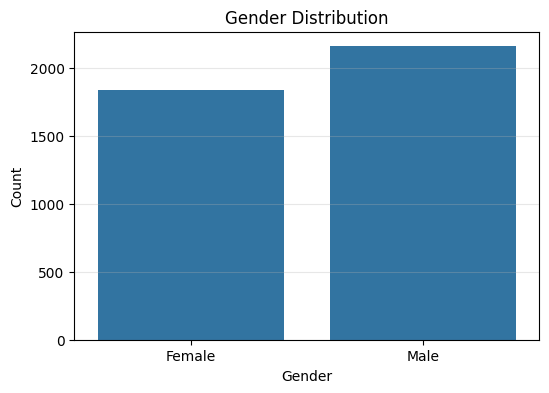

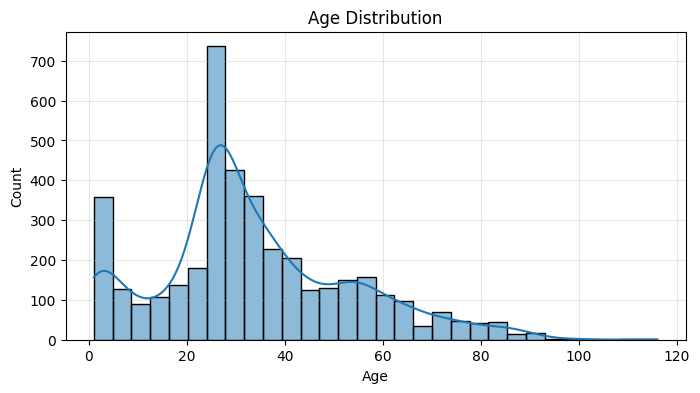

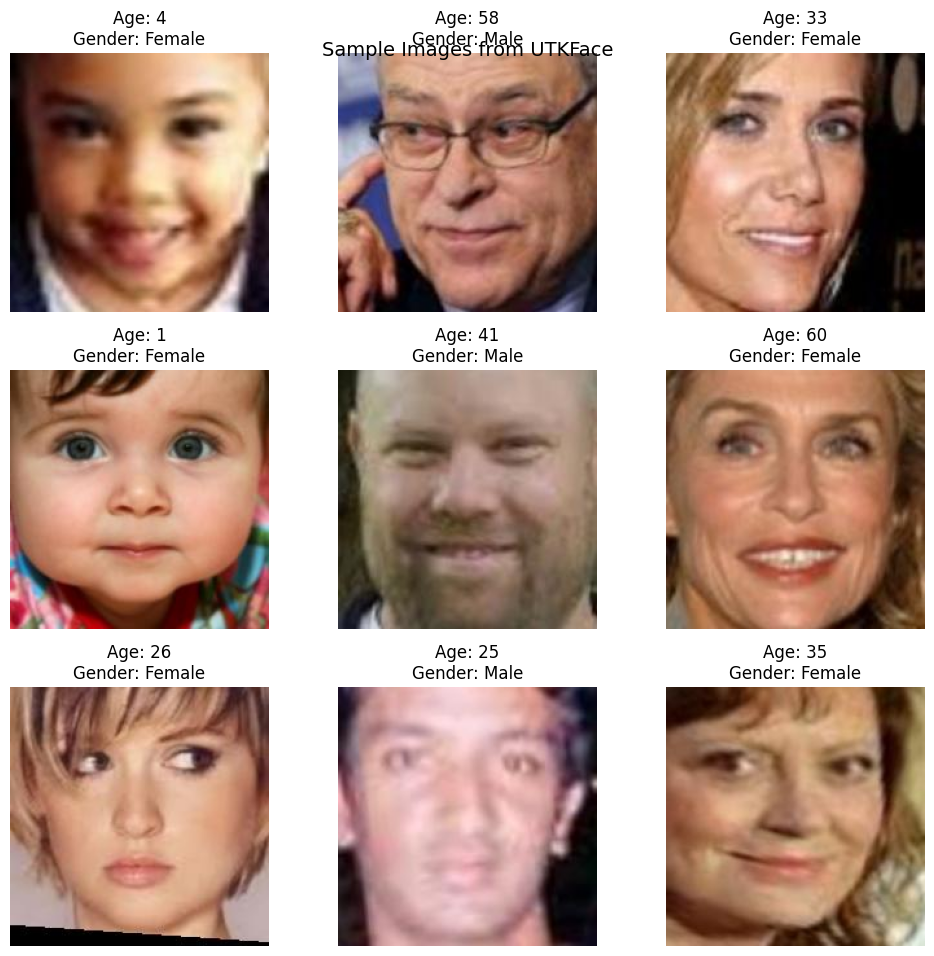

In [8]:
# -----------------------------
# 7. Quick EDA / visualizations
# -----------------------------
gender_map = {0: "Male", 1: "Female"}
data["gender_name"] = data["gender"].map(gender_map)

plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="gender_name")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

# show random sample images
sample_df = data.sample(9, random_state=SEED).reset_index(drop=True)
plt.figure(figsize=(10, 10))
for i, row in sample_df.iterrows():
    img = row["image_obj"].convert("RGB").convert("RGB")
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f'Age: {row["age"]}\nGender: {gender_map[row["gender"]]}')
    plt.axis("off")
plt.suptitle("Sample Images from UTKFace", y=0.92, fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# -----------------------------
# 8. Train / validation / test split
# -----------------------------
train_df, test_df = train_test_split(
    data,
    test_size=0.15,
    random_state=SEED,
    stratify=data["gender"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["gender"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nTrain size:", len(train_df))
print("Val size  :", len(val_df))
print("Test size :", len(test_df))


Train size: 2890
Val size  : 510
Test size : 600


In [10]:
# -----------------------------
# 9. TF input pipeline (RAM-safe)
# -----------------------------
def build_dataset(df, training=False):
    rows = df[["image_obj", "gender", "age"]].values.tolist()

    def generator():
        for img, gender, age in rows:
            if img is None:
                continue
            try:
                img_arr = np.array(img.convert("RGB"), dtype=np.float32)
                yield img_arr, {
                    "gender": np.array([gender], dtype=np.float32),
                    "age": np.array([age / AGE_MAX], dtype=np.float32)
                }
            except Exception:
                continue

    output_signature = (
        tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32),
        {
            "gender": tf.TensorSpec(shape=(1,), dtype=tf.float32),
            "age": tf.TensorSpec(shape=(1,), dtype=tf.float32),
        }
    )

    ds_tf = tf.data.Dataset.from_generator(generator, output_signature=output_signature)

    def _map(img, labels):
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

        if training:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.10)
            img = tf.image.random_contrast(img, 0.90, 1.10)

        img = preprocess_input(img)
        return img, labels

    if training:
        ds_tf = ds_tf.shuffle(buffer_size=min(len(df), 1000), seed=SEED)

    ds_tf = ds_tf.map(_map, num_parallel_calls=AUTOTUNE)
    ds_tf = ds_tf.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds_tf

train_ds = build_dataset(train_df, training=True)
val_ds = build_dataset(val_df, training=False)
test_ds = build_dataset(test_df, training=False)

In [11]:
# -----------------------------
# 10. Build multi-output model
# -----------------------------
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)

gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)
age_output = layers.Dense(1, activation="sigmoid", name="age")(x)  # normalized age

model = Model(inputs=inputs, outputs={"gender": gender_output, "age": age_output})

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "gender": "binary_crossentropy",
        "age": "mse"
    },
    loss_weights={
        "gender": 1.0,
        "age": 4.0
    },
    metrics={
        "gender": ["accuracy", tf.keras.metrics.AUC(name="auc")],
        "age": [tf.keras.metrics.MeanAbsoluteError(name="mae")]
    }
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 3, 3,      │  2,257,984 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        129 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# -----------------------------
# 11. Train - frozen backbone
# -----------------------------
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
    181/Unknown 38s 159ms/step - age_loss: 0.0406 - age_mae: 0.1570 - gender_accuracy: 0.6997 - gender_auc: 0.7615 - gender_loss: 0.5960 - loss: 0.7583

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


181/181 ━━━━━━━━━━━━━━━━━━━━ 45s 198ms/step - age_loss: 0.0286 - age_mae: 0.1315 - gender_accuracy: 0.7384 - gender_auc: 0.8112 - gender_loss: 0.5307 - loss: 0.6489 - val_age_loss: 0.0147 - val_age_mae: 0.0953 - val_gender_accuracy: 0.8176 - val_gender_auc: 0.8975 - val_gender_loss: 0.4002 - val_loss: 0.4733 - learning_rate: 0.0010
Epoch 2/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 41s 221ms/step - age_loss: 0.0177 - age_mae: 0.1034 - gender_accuracy: 0.7841 - gender_auc: 0.8634 - gender_loss: 0.4580 - loss: 0.5314 - val_age_loss: 0.0165 - val_age_mae: 0.1057 - val_gender_accuracy: 0.7863 - val_gender_auc: 0.9018 - val_gender_loss: 0.4037 - val_loss: 0.4848 - learning_rate: 0.0010
Epoch 3/5
181/181 ━━━━━━━━━━━━━━━━━━━━ 29s 156ms/step - age_loss: 0.0158 - age_mae: 0.0981 - gender_accuracy: 0.8128 - gender_auc: 0.8891 - gender_loss: 0.4171 - loss: 0.4832 - val_age_loss: 0.0129 - val_age_mae: 0.0894 - val_gender_accuracy: 0.7980 - val_gender_auc: 0.9086 - val_gender_loss: 0.3794 - val_loss: 0.4446 - 

In [13]:
# -----------------------------
# 12. Fine-tune last layers
# -----------------------------
base_model.trainable = True

# Freeze most of backbone, unfreeze only last few layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        "gender": "binary_crossentropy",
        "age": "mse"
    },
    loss_weights={
        "gender": 1.0,
        "age": 4.0
    },
    metrics={
        "gender": ["accuracy", tf.keras.metrics.AUC(name="auc")],
        "age": [tf.keras.metrics.MeanAbsoluteError(name="mae")]
    }
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/3
181/181 ━━━━━━━━━━━━━━━━━━━━ 61s 260ms/step - age_loss: 0.0232 - age_mae: 0.1197 - gender_accuracy: 0.7381 - gender_auc: 0.8283 - gender_loss: 0.5321 - loss: 0.6290 - val_age_loss: 0.0131 - val_age_mae: 0.0875 - val_gender_accuracy: 0.8235 - val_gender_auc: 0.9240 - val_gender_loss: 0.3430 - val_loss: 0.4077 - learning_rate: 1.0000e-05
Epoch 2/3
181/181 ━━━━━━━━━━━━━━━━━━━━ 46s 251ms/step - age_loss: 0.0209 - age_mae: 0.1138 - gender_accuracy: 0.7893 - gender_auc: 0.8728 - gender_loss: 0.4495 - loss: 0.5362 - val_age_loss: 0.0131 - val_age_mae: 0.0878 - val_gender_accuracy: 0.8235 - val_gender_auc: 0.9267 - val_gender_loss: 0.3343 - val_loss: 0.3989 - learning_rate: 1.0000e-05
Epoch 3/3
181/181 ━━━━━━━━━━━━━━━━━━━━ 83s 450ms/step - age_loss: 0.0200 - age_mae: 0.1107 - gender_accuracy: 0.7997 - gender_auc: 0.8866 - gender_loss: 0.4202 - loss: 0.5034 - val_age_loss: 0.0136 - val_age_mae: 0.0904 - val_gender_accuracy: 0.8314 - val_gender_auc: 0.9250 - val_gender_loss: 0.3367 - v

In [14]:
# -----------------------------
# 13. Merge training histories
# -----------------------------
def merge_histories(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history.get(key, [])
    return history

history = merge_histories(history1, history2)

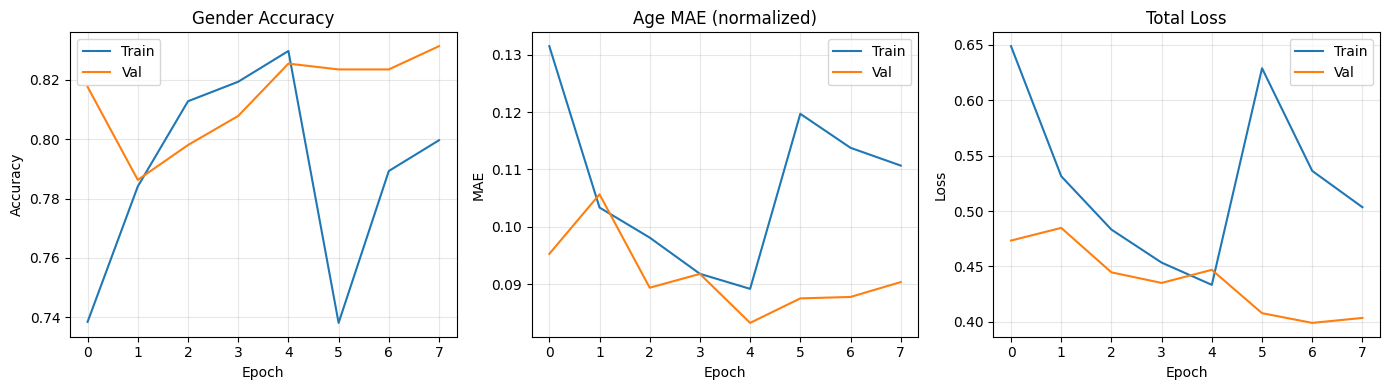

In [15]:
# -----------------------------
# 14. Plot training curves
# -----------------------------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history["gender_accuracy"], label="Train")
plt.plot(history["val_gender_accuracy"], label="Val")
plt.title("Gender Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history["age_mae"], label="Train")
plt.plot(history["val_age_mae"], label="Val")
plt.title("Age MAE (normalized)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history["loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# -----------------------------
# 15. Evaluate on test set
# -----------------------------
test_metrics = model.evaluate(test_ds, verbose=1)
print("\nTest metrics:", dict(zip(model.metrics_names, test_metrics)))

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - age_loss: 0.0152 - age_mae: 0.0934 - gender_accuracy: 0.8417 - gender_auc: 0.9250 - gender_loss: 0.3384 - loss: 0.4114

Test metrics: {'loss': 0.4113811254501343, 'compile_metrics': 0.33844995498657227, 'gender_loss': 0.015218711458146572, 'age_loss': 0.09343523532152176}


In [17]:
# -----------------------------
# 16. Predictions on test set
# -----------------------------
pred = model.predict(test_ds, verbose=1)

gender_probs = pred["gender"].reshape(-1)
age_preds_norm = pred["age"].reshape(-1)

gender_preds = (gender_probs >= 0.5).astype(int)
age_preds = age_preds_norm * AGE_MAX

y_gender_true = test_df["gender"].values
y_age_true = test_df["age"].values

38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step


In [18]:
# -----------------------------
# 17. Metrics
# -----------------------------
gender_acc = np.mean(gender_preds == y_gender_true)
age_mae = mean_absolute_error(y_age_true, age_preds)
age_rmse = math.sqrt(mean_squared_error(y_age_true, age_preds))
age_r2 = r2_score(y_age_true, age_preds)

print("\nFinal Test Summary")
print("Gender Accuracy :", round(gender_acc, 4))
print("Age MAE         :", round(age_mae, 4))
print("Age RMSE        :", round(age_rmse, 4))
print("Age R2          :", round(age_r2, 4))

print("\nGender Classification Report:")
print(classification_report(
    y_gender_true,
    gender_preds,
    target_names=["Male", "Female"]
))


Final Test Summary
Gender Accuracy : 0.8417
Age MAE         : 10.8385
Age RMSE        : 14.5058
Age R2          : 0.4593

Gender Classification Report:
              precision    recall  f1-score   support

        Male       0.84      0.88      0.86       324
      Female       0.85      0.80      0.82       276

    accuracy                           0.84       600
   macro avg       0.84      0.84      0.84       600
weighted avg       0.84      0.84      0.84       600



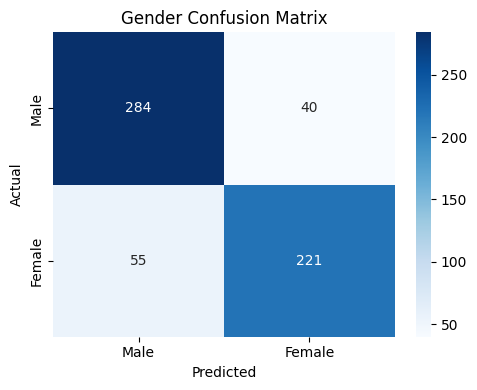

In [19]:
# -----------------------------
# 18. Confusion matrix for gender
# -----------------------------
cm = confusion_matrix(y_gender_true, gender_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Male", "Female"],
    yticklabels=["Male", "Female"]
)
plt.title("Gender Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

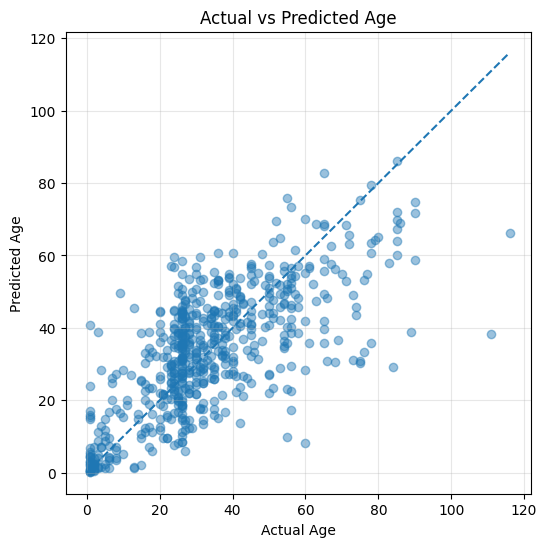

In [20]:
# -----------------------------
# 19. Age scatter plot
# -----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_age_true, age_preds, alpha=0.45)
plt.plot([0, 116], [0, 116], linestyle="--")
plt.title("Actual vs Predicted Age")
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.grid(alpha=0.3)
plt.show()

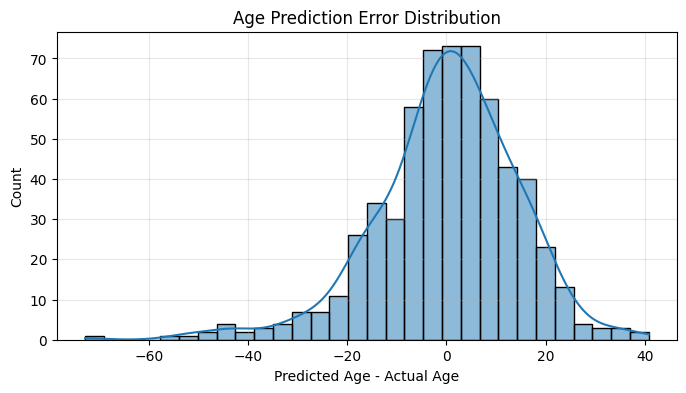

In [21]:
# -----------------------------
# 20. Error distribution for age
# -----------------------------
age_errors = age_preds - y_age_true

plt.figure(figsize=(8, 4))
sns.histplot(age_errors, bins=30, kde=True)
plt.title("Age Prediction Error Distribution")
plt.xlabel("Predicted Age - Actual Age")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

,image_obj,age,gender,race,gender_name,pred_gender,pred_gender_name,pred_age,gender_prob_female,age_abs_error
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,26,1,4,Female,1,Female,18.743927,0.964031,7.256073
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,26,1,2,Female,1,Female,34.345291,0.897007,8.345291
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,29,0,0,Male,0,Male,49.876289,0.149980,20.876289
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,36,0,0,Male,0,Male,52.000046,0.062944,16.000046
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,46,0,1,Male,0,Male,52.827682,0.083805,6.827682


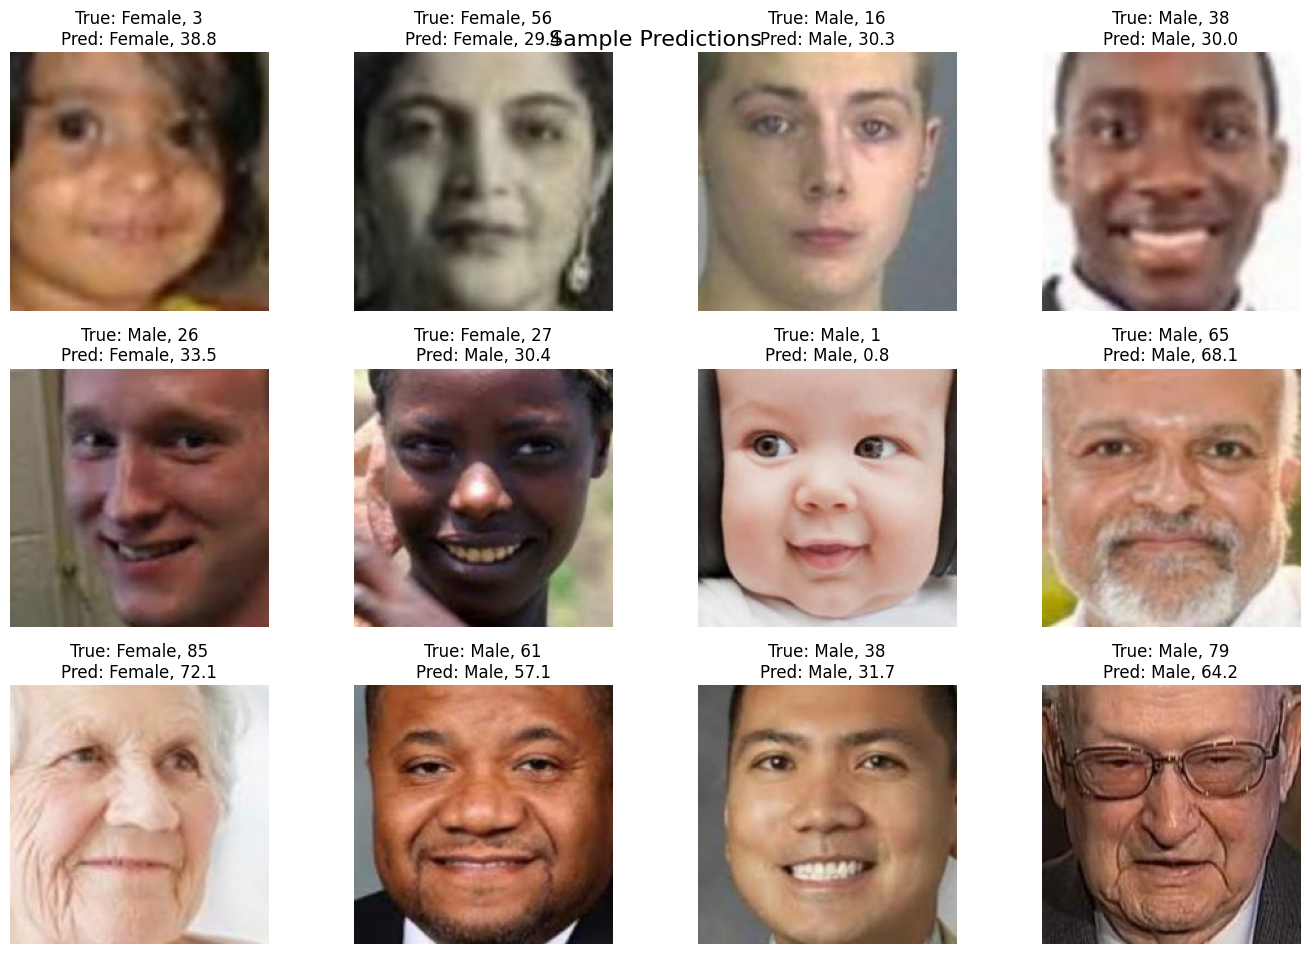

In [22]:
# -----------------------------
# 21. Sample prediction gallery
# -----------------------------
results_df = test_df.copy()
results_df["pred_gender"] = gender_preds
results_df["pred_gender_name"] = results_df["pred_gender"].map(gender_map)
results_df["pred_age"] = age_preds
results_df["gender_prob_female"] = gender_probs
results_df["age_abs_error"] = np.abs(results_df["pred_age"] - results_df["age"])

display(results_df.head())

sample_preds = results_df.sample(12, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(14, 10))
for i, row in sample_preds.iterrows():
    img = row["image_obj"].convert("RGB")
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(
        f"True: {gender_map[row['gender']]}, {int(row['age'])}\n"
        f"Pred: {row['pred_gender_name']}, {row['pred_age']:.1f}"
    )
    plt.axis("off")
plt.suptitle("Sample Predictions", y=0.93, fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
# -----------------------------
# 22. Save model and outputs
# -----------------------------
model.save("gender_age_detector_mobilenetv2.keras")
results_df.to_csv("test_predictions_gender_age.csv", index=False)

# save plots if needed
plt.figure(figsize=(6, 6))
plt.scatter(y_age_true, age_preds, alpha=0.45)
plt.plot([0, 116], [0, 116], linestyle="--")
plt.title("Actual vs Predicted Age")
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("age_scatter.png", dpi=200)
plt.close()

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Male", "Female"],
    yticklabels=["Male", "Female"]
)
plt.title("Gender Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("gender_confusion_matrix.png", dpi=200)
plt.close()

print("\nSaved:")
print("- gender_age_detector_mobilenetv2.keras")
print("- test_predictions_gender_age.csv")
print("- age_scatter.png")
print("- gender_confusion_matrix.png")


Saved:
- gender_age_detector_mobilenetv2.keras
- test_predictions_gender_age.csv
- age_scatter.png
- gender_confusion_matrix.png


In [24]:
# -----------------------------
# 23. Inference on a single image
# -----------------------------
def predict_single_image(image_path):
    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).astype("float32")
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    pred = model.predict(arr, verbose=0)
    gender_prob = float(pred["gender"][0][0])
    gender_label = "Female" if gender_prob >= 0.5 else "Male"
    age_value = float(pred["age"][0][0] * AGE_MAX)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicted: {gender_label}, Age {age_value:.1f}")
    plt.axis("off")
    plt.show()

    return {
        "predicted_gender": gender_label,
        "female_probability": gender_prob,
        "predicted_age": age_value
    }

# Example:
# predict_single_image(test_df.loc[0, "filepath"])